# Seasonality for real: the Keeling curve under four tools

Notebook 01 built the Fourier toolkit on signals we manufactured.
This one points it at one of the most famous time series in science,
and the encounter does not begin well: the first thing the raw FFT
does on real data is fail, instructively.

The data is the **Keeling curve**: monthly mean atmospheric CO2
measured on the slopes of Mauna Loa volcano in Hawaii, started by
Charles David Keeling in 1958 and maintained ever since, now by NOAA's
Global Monitoring Laboratory. Our snapshot ships with this repository
(sixty-eight years, 1958 to mid-2026) and `data/build_dataset.py`
refreshes it from NOAA's public file whenever you like. The 2020
version of this tutorial relied on a CSV living outside the repository,
which is why it no longer ran; data now travels with the code.

Two things are happening in this series at very different speeds, and
that tension powers the whole notebook. CO2 rises decade over decade,
from 315 ppm (parts per million) when measurement began to above 430
now. And each year breathes: Northern Hemisphere plants draw carbon
down all growing season, then release it through fall and winter
decay. A yearly sawtooth about 6 ppm tall, riding a 115 ppm climb.

The mission: detect that yearly cycle properly, measure its size, and
confirm the finding with tools that share no assumptions. Along the
way we meet the single most common practical mistake in spectral
analysis, and fix it properly.

820 monthly values, 1958-03 to 2026-06, 312.4 to 432.3 ppm


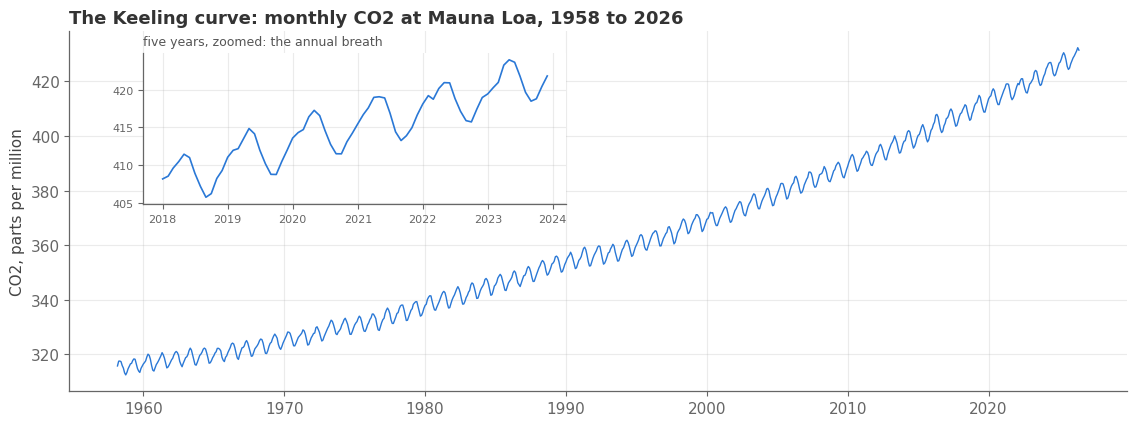

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from numpy.fft import rfft, rfftfreq

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, GRAY, INK = '#fab219', '#d03b3b', '#8a8f98', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

co2 = (pd.read_csv('../data/co2_mm_mlo.csv', parse_dates=['date'])
       .set_index('date')['co2'])

fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.plot(co2.index, co2, color=BLUE, lw=1.0)
ax.set_ylabel('CO2, parts per million')
ax.set_title('The Keeling curve: monthly CO2 at Mauna Loa, 1958 to 2026')
axins = ax.inset_axes([0.07, 0.52, 0.40, 0.42])
recent = co2.loc['2018':'2023']
axins.plot(recent.index, recent, color=BLUE, lw=1.2)
axins.set_title('five years, zoomed: the annual breath', fontsize=9,
                color='#555555', fontweight='normal')
axins.tick_params(labelsize=8)
axins.grid(alpha=0.25)
fig.tight_layout()
fig.savefig('../pic/keeling_curve.png', dpi=150, bbox_inches='tight',
            facecolor='white')

print(f"{len(co2)} monthly values, {co2.index.min():%Y-%m} to "
      f"{co2.index.max():%Y-%m}, {co2.min():.1f} to {co2.max():.1f} ppm")

The zoom shows the quarry: each year rises to a peak in May, dips to a
trough around October. Now let us pretend we do not know that, and go
hunting with the FFT, the way notebook 01 taught.

## The mistake everyone makes first

Feed the series to `rfft` directly (mean removed, since the constant
offset is not a cycle). Frequencies are in cycles per year, because we
pass `d=1/12`: our samples are one twelfth of a year apart.

tallest peak: 0.0146 cycles/year with amplitude 36.5 ppm


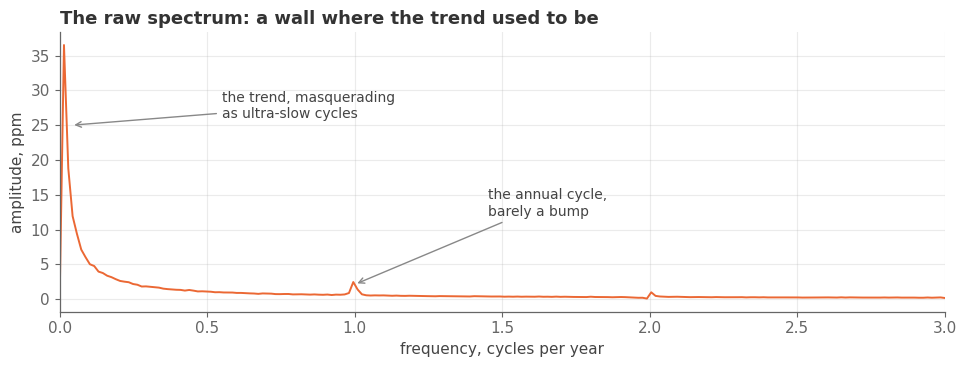

In [2]:
n = len(co2)
freqs = rfftfreq(n, d=1 / 12)               # cycles per year
amp_raw = np.abs(rfft((co2 - co2.mean()).values)) * 2 / n

fig, ax = plt.subplots(figsize=(9.8, 3.8))
ax.plot(freqs, amp_raw, color=ORANGE, lw=1.4)
ax.set_xlim(0, 3)
ax.set_xlabel('frequency, cycles per year')
ax.set_ylabel('amplitude, ppm')
ax.set_title('The raw spectrum: a wall where the trend used to be')
ax.annotate('the trend, masquerading\nas ultra-slow cycles',
            xy=(0.04, 25), xytext=(0.55, 26), fontsize=10, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
ax.annotate('the annual cycle,\nbarely a bump',
            xy=(1.0, 2.1), xytext=(1.45, 12), fontsize=10, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
fig.tight_layout()

k = np.argmax(amp_raw[1:]) + 1
print(f"tallest peak: {freqs[k]:.4f} cycles/year with amplitude "
      f"{amp_raw[k]:.1f} ppm")

The spectrum is dominated by an enormous wall at the lowest
frequencies, and the annual cycle we came for is a foothill beside
it. Nothing is wrong with the FFT. The problem is what we asked it to
explain. To Fourier analysis, a 115 ppm rise across the record is
indistinguishable from one arm of a cycle too slow to fit in the
window, so it spends its lowest-frequency components describing the
trend, and (notebook 01's leakage lesson, at full scale) smears that
energy well up the frequency axis. The old notebook handled the
wall by silently dropping the first two frequency bins. That hides
the symptom and leaves the leakage. The real fix is to remove the
trend *before* the transform.

## Detrend, then transform

Separating the two speeds is one line. A **12-month centered rolling
mean** follows the slow climb but averages the seasonal wiggle away
(a full year of seasonal ups and downs sums to roughly zero by
definition), so subtracting it leaves exactly what we want to study:
the **anomalies**, each month's deviation from its year's baseline.
Differencing or STL (later in this notebook) are alternatives; for a
smooth trend like this one, the rolling mean is the easiest to reason
about. One bookkeeping note: the rolling mean has no value in its
first and last half-window, so the anomaly record is 809 months, 67.4
years, and that duration sets the frequency grid below.

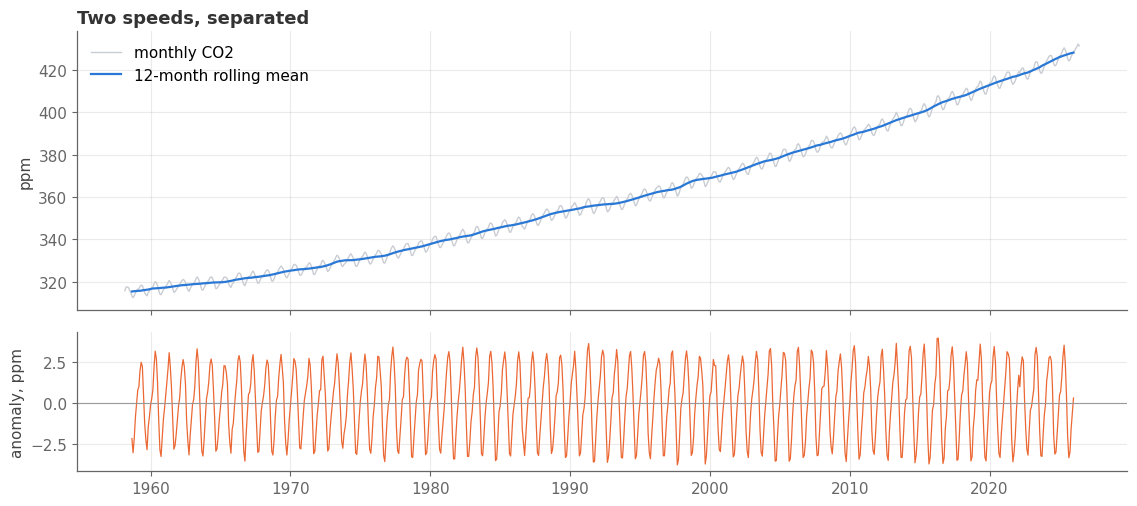

In [3]:
trend = co2.rolling(12, center=True).mean()
anom = (co2 - trend).dropna()

fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.2), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(co2.index, co2, color='#c9cdd3', lw=1.0, label='monthly CO2')
axes[0].plot(trend.index, trend, color=BLUE, lw=1.6,
             label='12-month rolling mean')
axes[0].set_ylabel('ppm')
axes[0].legend(loc='upper left')
axes[0].set_title('Two speeds, separated')
axes[1].plot(anom.index, anom, color=ORANGE, lw=0.9)
axes[1].axhline(0, color='#999999', lw=0.8)
axes[1].set_ylabel('anomaly, ppm')
fig.tight_layout()

The lower panel is the annual breath, isolated: a steady oscillation
a few ppm either side of zero for sixty-eight years. Now the spectrum
has a fair question to answer. (No window this time: with the trend
gone there is no monster component left to leak, and we will bring
windows back when amplitude precision matters in a moment.)

,cycles per year,"amplitude, ppm","period, months"
0,0.994,2.018,12.075
1,2.002,0.785,5.993


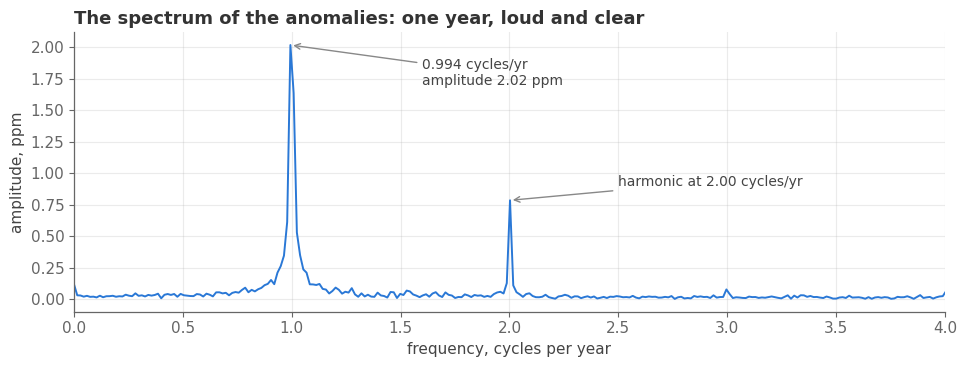

In [4]:
nd = len(anom)
fd = rfftfreq(nd, d=1 / 12)
amp = np.abs(rfft(anom.values)) * 2 / nd

fig, ax = plt.subplots(figsize=(9.8, 3.8))
ax.plot(fd, amp, color=BLUE, lw=1.4)
ax.set_xlim(0, 4)
ax.set_xlabel('frequency, cycles per year')
ax.set_ylabel('amplitude, ppm')
ax.set_title('The spectrum of the anomalies: one year, loud and clear')
k1 = np.argmax(amp[1:]) + 1
ax.annotate(f'{fd[k1]:.3f} cycles/yr\namplitude {amp[k1]:.2f} ppm',
            xy=(fd[k1], amp[k1]), xytext=(1.6, 1.7), fontsize=10,
            color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
k2 = np.argmin(np.abs(fd - 2.0))
k2 = k2 - 1 + np.argmax(amp[k2 - 1:k2 + 2])
ax.annotate(f'harmonic at {fd[k2]:.2f} cycles/yr',
            xy=(fd[k2], amp[k2]), xytext=(2.5, 0.9), fontsize=10,
            color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
fig.tight_layout()
fig.savefig('../pic/co2_spectrum.png', dpi=150, bbox_inches='tight',
            facecolor='white')

peaks = pd.DataFrame({'cycles per year': fd[[k1, k2]],
                      'amplitude, ppm': amp[[k1, k2]]})
peaks['period, months'] = 12 / peaks['cycles per year']
peaks.round(3)

The wall is gone and the annual peak owns the picture. The little
table translates frequencies into units a human plans in, months, a
habit the original notebook got right and we keep: a peak at 0.994
cycles per year is a period of 12.07 months.

Two readings deserve care, because both teach something general.

**Why 12.07 months and not 12.00?** The FFT can only report
frequencies on a grid spaced 1/duration apart, here 1/67.4 years.
The true annual frequency falls between two grid points, and we see
the nearest one. Frequency resolution is bought with record length
and nothing else; a longer record sharpens the estimate, a shorter
one blurs it. Falling between grid points has a second cost, quieter
and more dangerous, that the reconciliation below will expose: it
also shaves height off the peak.

**Why a second peak at two cycles per year?** Not because something
in nature repeats every six months. The seasonal shape is a lopsided
sawtooth (slow buildup, steep drawdown), and notebook 01's chord
lesson runs in reverse: a repeating non-sine shape *is* a chord, a
fundamental plus harmonics at integer multiples. The 0.79 ppm
harmonic is part of the annual cycle's shape, not a separate
phenomenon. Harmonics will matter again in notebook 03, where they
encode rush hours.

## Second witness: just average the months

Sixty-eight Januaries, sixty-eight Julys. The plainest measurement
of a seasonal cycle available to anyone: group the anomalies by
calendar month and average. No transforms, no windows, no grids.

peak month: May (+3.11 ppm), trough: October (-3.18 ppm), swing 6.29 ppm


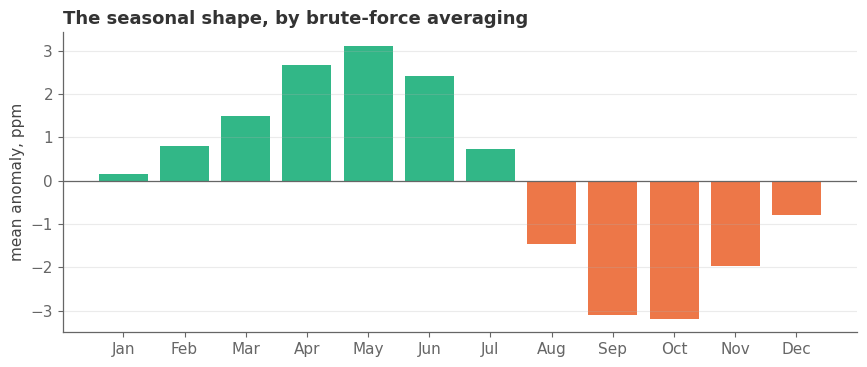

In [5]:
clim = anom.groupby(anom.index.month).mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(8.8, 3.8))
ax.bar(months, clim.values, color=[GREEN if v > 0 else ORANGE
                                   for v in clim.values], alpha=0.9)
ax.axhline(0, color='#666666', lw=0.9)
ax.set_ylabel('mean anomaly, ppm')
ax.set_title('The seasonal shape, by brute-force averaging')
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', alpha=0)
fig.tight_layout()

swing = clim.max() - clim.min()
print(f"peak month: May ({clim[5]:+.2f} ppm), trough: October "
      f"({clim[10]:+.2f} ppm), swing {swing:.2f} ppm")

May peak, October trough, total swing 6.3 ppm. Now reconcile the two
witnesses, because at first glance they disagree badly: the spectrum
read a fundamental of 2.02 ppm, which suggests a peak-to-trough of
about 4 ppm, yet the month-by-month averaging says 6.3. Two culprits
are at work, and naming both is worth the detour, because one of
them bites every practitioner who reads amplitudes off an FFT.

The first culprit is the off-grid offset we just met. When the true
frequency falls between grid points, the nearest bin does not
receive all of the cycle's energy: some spills into the neighboring
bin, and the peak's measured height drops. Our annual line sits
about 0.4 bins off the grid, enough to shave nearly thirty percent
off the reading. The second culprit is the harmonics: the fundamental
is only the sine-shaped part of the cycle, and the lopsided sawtooth
needs its overtones to reach full height.

Accusations require arithmetic, so the next cell measures the
fundamental properly, by least-squares regression at *exactly* one
cycle per year (regression is not confined to the FFT's grid), adds
the harmonics the same way, and rebuilds the seasonal swing from the
parts.

In [6]:
t_yr = np.arange(nd) / 12
cols = []
for f_ in (1, 2, 3):
    cols += [np.sin(2 * np.pi * f_ * t_yr), np.cos(2 * np.pi * f_ * t_yr)]
X = np.column_stack(cols)
beta, *_ = np.linalg.lstsq(X, anom.values, rcond=None)
amps = [float(np.hypot(beta[2 * i], beta[2 * i + 1])) for i in range(3)]

print("amplitude by regression, off the grid's leash:")
for f_, a_ in zip((1, 2, 3), amps):
    print(f"  {f_} cycle(s)/year: {a_:.2f} ppm")

hann = np.hanning(nd)
amp_hann = np.abs(rfft(anom.values * hann)) * 2 / hann.sum()
print(f"\nnearest-bin FFT readout      : {amp[k1]:.2f} ppm")
print(f"Hann-windowed FFT readout    : {amp_hann[np.argmax(amp_hann[1:]) + 1]:.2f} ppm")
print(f"regression at exactly 1/yr   : {amps[0]:.2f} ppm")

recon = X @ beta
rec_clim = pd.Series(recon, index=anom.index).groupby(anom.index.month).mean()
print(f"\nswing rebuilt from 3 components: "
      f"{rec_clim.max() - rec_clim.min():.2f} ppm  "
      f"(climatology said {swing:.2f})")

amplitude by regression, off the grid's leash:
  1 cycle(s)/year: 2.84 ppm
  2 cycle(s)/year: 0.80 ppm
  3 cycle(s)/year: 0.07 ppm

nearest-bin FFT readout      : 2.02 ppm
Hann-windowed FFT readout    : 2.53 ppm
regression at exactly 1/yr   : 2.84 ppm

swing rebuilt from 3 components: 6.26 ppm  (climatology said 6.29)


/var/folders/b1/94dlslw92s1_0hgryxdz2v780000gn/T/ipykernel_22550/2485649871.py:19: RuntimeWarning: divide by zero encountered in matmul
  recon = X @ beta
/var/folders/b1/94dlslw92s1_0hgryxdz2v780000gn/T/ipykernel_22550/2485649871.py:19: RuntimeWarning: overflow encountered in matmul
  recon = X @ beta
/var/folders/b1/94dlslw92s1_0hgryxdz2v780000gn/T/ipykernel_22550/2485649871.py:19: RuntimeWarning: invalid value encountered in matmul
  recon = X @ beta


The accounting closes. The true fundamental is 2.84 ppm, not the
2.02 the nearest bin reported: the off-grid offset cost nearly
thirty percent of the height, and a Hann window (notebook 01's tool)
recovers part of the loss without leaving the FFT. The harmonics contribute the rest,
and rebuilding the cycle from the regression's three components
reproduces the climatology's swing almost exactly.

Neither witness was wrong, but they answer different questions, and
the spectrum's answer comes with a caveat the axis label never
states: a nearest-bin amplitude is a *floor*, not a measurement,
whenever the true frequency lives between grid points. Position and
height both suffer off-grid. When the amplitude itself is the
deliverable, measure it by regression at the exact frequency, or at
least window first.

## Names worth getting right

One terminology repair, because the 2020 version of this tutorial
(like many others) used the wrong word. The quantity we have been
plotting, $2|X_k|/N$, is an **amplitude spectrum**: it answers "how
big is the cycle, in data units". A **periodogram**, what
`scipy.signal.periodogram` returns, is a *power* spectral density:
amplitude squared, spread per unit of frequency, with units like
ppm² per cycle-per-year. Power form is the convention in physics and
engineering; amplitude form is friendlier for "how many ppm is the
annual swing". Same information, different scaling. Both find the
same peak, which is worth demonstrating once:

In [7]:
from scipy.signal import periodogram

f_p, pxx = periodogram(anom.values, fs=12)   # fs in samples per year
print(f"periodogram peak at {f_p[np.argmax(pxx)]:.4f} cycles/year "
      f"(amplitude spectrum said {fd[k1]:.4f})")

periodogram peak at 0.9938 cycles/year (amplitude spectrum said 0.9938)


## Third witness: the autocorrelation function

The spectrum lives in frequency. Its time-domain sibling, the
**autocorrelation function** (ACF), asks a question anyone can act
out with a ruler: slide the series alongside a copy of itself, delay
by delay, and measure the correlation at each lag. A cycle of twelve
months makes the series agree with itself at lag 12 (and 24, and 36),
and *disagree* at lag 6, when peaks line up against troughs.

ACF at lag 12: +0.972   lag 24: +0.959
ACF at lag  6: -0.833   lag 18: -0.821


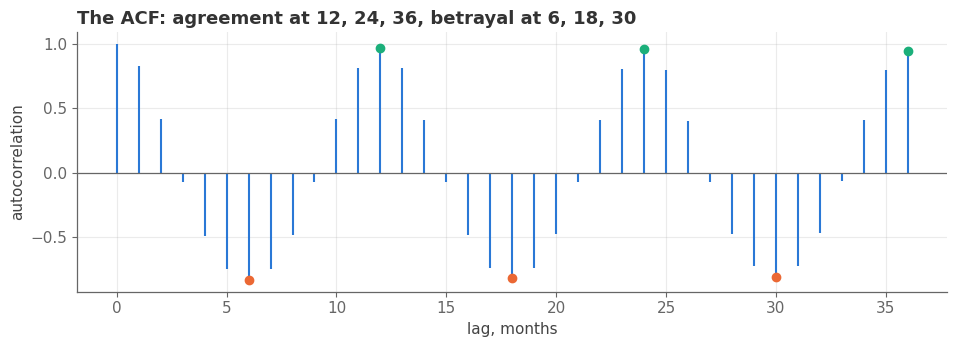

In [8]:
from statsmodels.tsa.stattools import acf

lags = 37
a = acf(anom, nlags=lags - 1)

fig, ax = plt.subplots(figsize=(9.8, 3.6))
ax.stem(range(lags), a, basefmt=' ', linefmt=BLUE, markerfmt=' ')
for lag, color in ((12, GREEN), (24, GREEN), (36, GREEN), (6, ORANGE),
                   (18, ORANGE), (30, ORANGE)):
    ax.plot(lag, a[lag], 'o', color=color, ms=6)
ax.axhline(0, color='#666666', lw=0.9)
ax.set_xlabel('lag, months')
ax.set_ylabel('autocorrelation')
ax.set_title('The ACF: agreement at 12, 24, 36, betrayal at 6, 18, 30')
fig.tight_layout()

print(f"ACF at lag 12: {a[12]:+.3f}   lag 24: {a[24]:+.3f}")
print(f"ACF at lag  6: {a[6]:+.3f}   lag 18: {a[18]:+.3f}")

Near-perfect memory at multiples of a year (0.97 at lag 12), strong
anti-correlation at the half cycle (-0.83 at lag 6). The ACF and the
spectrum are two views of the same mathematics, and when they
disagree about the period of a series, believe neither until you know
why. As a lone tool the ACF is the more robust period detector on
short or ragged records; the spectrum earns its keep by measuring
amplitudes and separating multiple overlapping cycles.

## Fourth witness: STL decomposition

The modern workhorse for "trend plus season plus noise" is **STL**
(Seasonal-Trend decomposition using Loess), which fits all three
components at once and, unlike our rolling mean, lets the seasonal
pattern drift slowly over decades. It replaces the
`seasonal_decompose` call from the original notebook, whose old call
signature no longer works in statsmodels. If STL's seasonal component is a clean
annual cycle, our whole chain of reasoning gets an independent
confirmation.

FFT of STL's seasonal component peaks at 0.9951 cycles/year
STL seasonal swing, first two decades: 6.2 ppm peak to trough
STL seasonal swing, last two decades : 7.1 ppm peak to trough


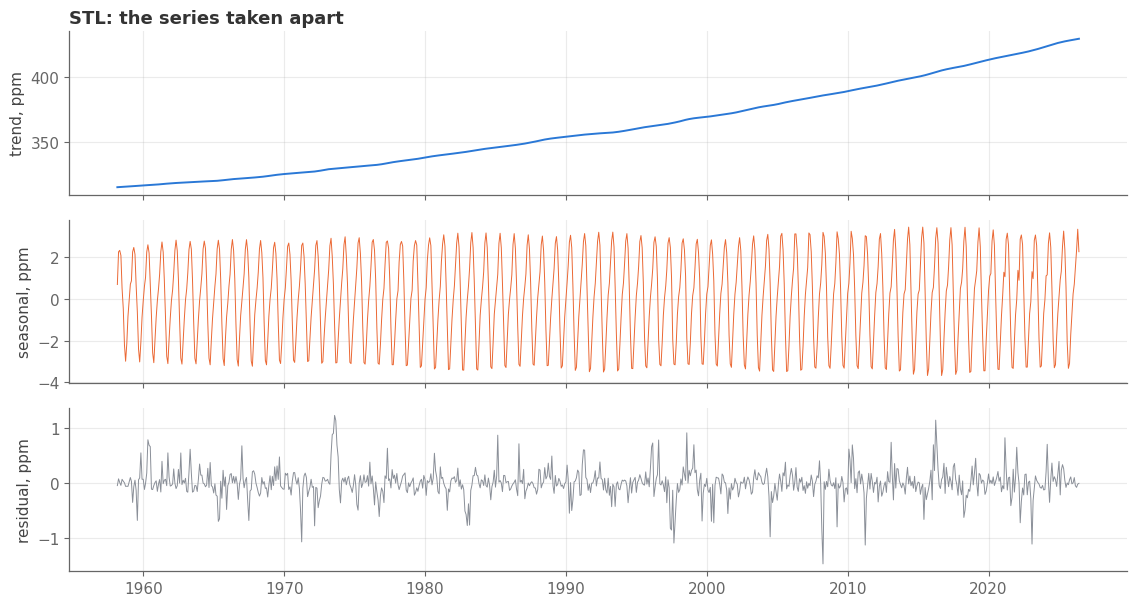

In [9]:
from statsmodels.tsa.seasonal import STL

stl = STL(co2, period=12, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(11.5, 6.2), sharex=True)
axes[0].plot(co2.index, stl.trend, color=BLUE, lw=1.4)
axes[0].set_ylabel('trend, ppm')
axes[0].set_title('STL: the series taken apart')
axes[1].plot(co2.index, stl.seasonal, color=ORANGE, lw=0.7)
axes[1].set_ylabel('seasonal, ppm')
axes[2].plot(co2.index, stl.resid, color=GRAY, lw=0.7)
axes[2].set_ylabel('residual, ppm')
fig.tight_layout()

s = stl.seasonal.values
amp_s = np.abs(rfft(s - s.mean())) * 2 / len(s)
print(f"FFT of STL's seasonal component peaks at "
      f"{freqs[np.argmax(amp_s[1:]) + 1]:.4f} cycles/year")
print(f"STL seasonal swing, first two decades: "
      f"{stl.seasonal[:240].max() - stl.seasonal[:240].min():.1f} ppm "
      f"peak to trough")
print(f"STL seasonal swing, last two decades : "
      f"{stl.seasonal[-240:].max() - stl.seasonal[-240:].min():.1f} ppm "
      f"peak to trough")

The seasonal panel is the annual cycle again, and its spectrum is
dominated by the one-cycle-per-year line, with the familiar
semiannual harmonic in tow. STL also reveals a subtlety our
fixed climatology averaged over: the seasonal swing has grown, from
6.2 ppm peak to trough in the record's first two decades to 7.1 in
its last two, a real geophysical finding consistent with a more
productive Northern Hemisphere biosphere. Four tools now agree on
the what; the richer ones add texture to the how much.

## Is the peak real? Ask permutation

Every method above found the annual cycle because it is enormous. In
messier data (and in notebook 03's residuals) you will meet peaks of
ambiguous size, so the series needs a referee: a significance
test with no formulas to misremember.

The logic: if the anomalies had no temporal structure, their values
would be exchangeable, so **shuffle them**. Shuffling keeps every
value (same overall variance) but destroys the ordering that makes a
cycle a cycle. Compute the spectrum of each shuffle, record its
tallest peak anywhere, repeat a thousand times, and you have the
distribution of the biggest peak pure chance produces from this very
data. Then look where the real peak falls.

observed peak: 2.02 ppm; largest of 1000 shuffles: 0.57 ppm; p < 0.001


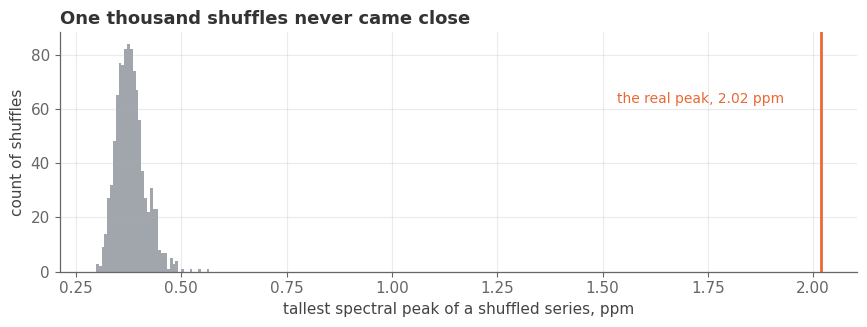

In [10]:
rng = np.random.default_rng(0)
null_peaks = np.array([
    (np.abs(rfft(rng.permutation(anom.values))) * 2 / nd)[1:].max()
    for _ in range(1000)])

fig, ax = plt.subplots(figsize=(8.8, 3.4))
ax.hist(null_peaks, bins=40, color=GRAY, alpha=0.8)
ax.axvline(amp[k1], color=ORANGE, lw=2)
ax.annotate(f'the real peak, {amp[k1]:.2f} ppm', xy=(amp[k1], 60),
            xytext=(1.93, 62), ha='right', fontsize=10, color=ORANGE)
ax.set_xlabel('tallest spectral peak of a shuffled series, ppm')
ax.set_ylabel('count of shuffles')
ax.set_title('One thousand shuffles never came close')
fig.tight_layout()

print(f"observed peak: {amp[k1]:.2f} ppm; largest of 1000 shuffles: "
      f"{null_peaks.max():.2f} ppm; p < 0.001")

The tallest peak chance ever produced was 0.57 ppm; the real one is
2.02. (The p-value is nothing mysterious: it is the fraction of
shuffles that beat the real peak, and zero out of a thousand means p
sits below one in a thousand.) When you report a cycle to anyone who
will make a decision on it, attach this test or one like it. It
costs twenty lines and converts "there is a bump in my chart" into a
defensible claim.

One boundary to respect, though. Shuffling destroys *all* temporal
structure, so beating the shuffles proves the series has structure,
not necessarily a cycle: a trending or strongly autocorrelated
series with no period in it also beats its own shuffles easily. For
data like that (notebook 03's traffic residuals qualify), the fair
comparison is a matched red-noise null: simulate series with the
same one-step autocorrelation, or permute in blocks, and race the
peak against those instead.

## Where the tools break: a stress test

One last experiment, because a comparison of tools is worthless
without their failure points. We manufacture twenty years of monthly
data with a known annual cycle of amplitude 1, bury it under noise of
increasing size, and record how often each detector still finds a
period of twelve months: the spectrum (tallest peak within a bin or
two of the annual frequency), and the ACF (tallest peak among lags 2
to 30 landing within one lag of twelve, a tolerance matched to the
spectrum's so the contest is fair). Fifty trials per noise level.

lags elected by the ACF's low-noise misses (sigma <= 1): [23, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 25]


,noise sigma,spectrum,ACF
0,0.5,1.00,0.82
1,1.0,1.00,0.86
2,2.0,1.00,0.36
3,3.0,0.78,0.38
4,4.0,0.26,0.20
5,6.0,0.20,0.18
6,8.0,0.06,0.16
7,12.0,0.08,0.14


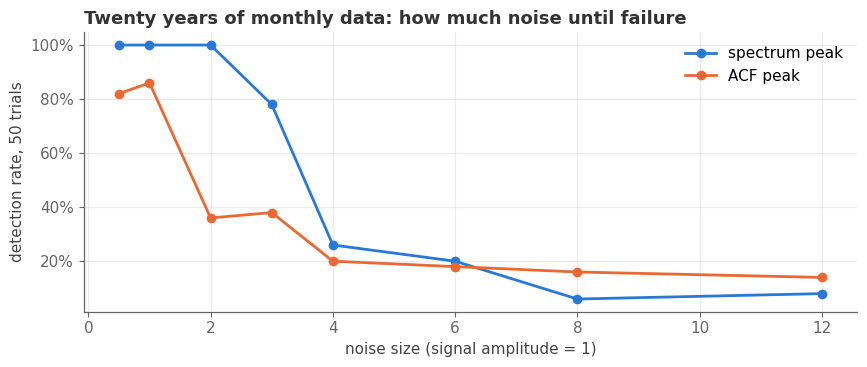

In [11]:
def spectrum_finds(x):
    a_ = np.abs(rfft(x - x.mean())) * 2 / len(x)
    f_ = rfftfreq(len(x), d=1 / 12)
    return abs(f_[np.argmax(a_[1:]) + 1] - 1.0) < 0.1

def acf_peak_lag(x):
    a_ = acf(x, nlags=30)
    return int(np.argmax(a_[2:]) + 2)

rng = np.random.default_rng(1)
months_n = 240
t_m = np.arange(months_n)
season = np.sin(2 * np.pi * t_m / 12)

noise_levels = [0.5, 1, 2, 3, 4, 6, 8, 12]
rows, low_noise_misses = [], []
for sigma in noise_levels:
    hits_f = hits_a = 0
    for _ in range(50):
        x = season + rng.normal(0, sigma, months_n)
        hits_f += spectrum_finds(x)
        lag = acf_peak_lag(x)
        hit = abs(lag - 12) <= 1
        hits_a += hit
        if not hit and sigma <= 1:
            low_noise_misses.append(lag)
    rows.append((sigma, hits_f / 50, hits_a / 50))
sweep = pd.DataFrame(rows, columns=['noise sigma', 'spectrum', 'ACF'])

print(f"lags elected by the ACF's low-noise misses (sigma <= 1): "
      f"{sorted(low_noise_misses)}")

fig, ax = plt.subplots(figsize=(8.8, 3.8))
ax.plot(sweep['noise sigma'], sweep['spectrum'], marker='o', color=BLUE,
        lw=2, label='spectrum peak')
ax.plot(sweep['noise sigma'], sweep['ACF'], marker='o', color=ORANGE,
        lw=2, label='ACF peak')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('noise size (signal amplitude = 1)')
ax.set_ylabel('detection rate, 50 trials')
ax.set_title('Twenty years of monthly data: how much noise until failure')
ax.legend()
fig.tight_layout()

sweep

The table teaches three separate lessons, and only one of them is
the ranking.

First, the spectrum: untouched by noise twice the signal's size,
degrading through three and four times, and down at its guessing
floor beyond that. That resilience is notebook 01's averaging
argument at work: a coherent cycle piles up in one bin while noise
spreads thinly over all of them, and it deepens with record length.

Second, the ACF rule stumbles even at low noise, and its stumbles
are not random: the printed tally shows the low-noise misses electing
lag 24 and its immediate neighbors. That is not a hallucination, it
is the period's own multiple (a cycle that repeats every 12 months
also matches itself at 24), and any naive tallest-ACF-peak detector
inherits this ambiguity between a period and its multiples. The
spectrum is structurally immune: harmonics land at twice the
*frequency*, nowhere near the fundamental's bin.

Third, the tails: both curves flatten onto their chance floors
rather than zero, which is what guessing looks like when the
detector has a tolerance window.

The portable conclusion is not "spectrum good, ACF bad". A smarter
ACF rule (test lag 12 directly, or fold multiples together) closes
much of the gap, and on records too short for a fine frequency grid
the ordering can reverse. The conclusion is that every detector has
failure modes and a noise level where it starts lying, and one
synthetic sweep like this, matched to your data's shape, tells you
where you stand before your real data gets a chance to fool you.

## Takeaways

1. Detrend before you transform. A trend is one arm of a cycle too
   slow to fit your window, and it will flood the spectrum with
   leakage if you let it. Dropping low bins hides the symptom while
   the leakage stays.
2. Read peaks with both eyes open: the frequency grid's resolution
   is 1/duration, and a true frequency living between grid points
   loses both position and height (ours read 12.07 months and 2.0
   ppm for a cycle whose real values are 12.00 and 2.8). Harmonics
   are the shape of your season, not extra seasons.
3. Confirm across families: the spectrum, brute-force climatology,
   the ACF, and STL rest on different assumptions, and their
   agreement, including a reconciled amplitude story, is what makes
   a finding solid.
4. Attach significance. A permutation test converts a bump into a
   claim, and a synthetic stress test tells you where your tools
   stop working.

Notebook 03 takes exactly this discipline somewhere a business would
pay for it: thirty-three months of hourly demand, a spectrum full of
harmonics and sidebands, and the question "so how many people do we
schedule for Tuesday 8am".

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*